In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as p
import shap

c:\Users\Barun Rawat\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df=pd.read_csv("placementdata.csv")
df.sample(5)

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
1357,1358,7.6,1,1,1,75,3.9,No,Yes,62,70,NotPlaced
3292,3293,6.5,1,2,0,83,4.5,No,No,69,71,NotPlaced
1433,1434,7.8,1,1,1,83,4.8,Yes,Yes,62,64,Placed
7098,7099,7.6,1,3,2,90,4.8,Yes,Yes,60,83,NotPlaced
751,752,8.2,2,3,1,79,4.8,Yes,Yes,79,86,Placed


In [4]:
df.columns

Index(['StudentID', 'CGPA', 'Internships', 'Projects',
       'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating',
       'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks',
       'HSC_Marks', 'PlacementStatus'],
      dtype='str')

In [5]:
df.shape

(10000, 12)

In [6]:
df=df.drop(columns=['StudentID'])

In [7]:
df=df.rename(columns={'AptitudeTestScore':'Aptitude_score','ExtracurricularActivities':'Extracurricular','PlacementTraining':'Training','PlacementStatus':'Placement','Workshops/Certifications':'Certifications','SSC_Marks':'10th_Marks','HSC_Marks':'12th_Marks'})
df.sample()

,CGPA,Internships,Projects,Certifications,Aptitude_score,SoftSkillsRating,Extracurricular,Training,10th_Marks,12th_Marks,Placement
89,7.2,1,2,0,68,4.2,Yes,Yes,57,66,NotPlaced


In [8]:
mapping={'Placed':1,'NotPlaced':0}
df['Placement']=df['Placement'].map(mapping)
df.sample(2)

,CGPA,Internships,Projects,Certifications,Aptitude_score,SoftSkillsRating,Extracurricular,Training,10th_Marks,12th_Marks,Placement
811,7.6,1,1,0,79,3.9,No,No,57,62,0
8881,7.8,1,2,1,70,3.9,No,Yes,58,70,0


<Axes: >

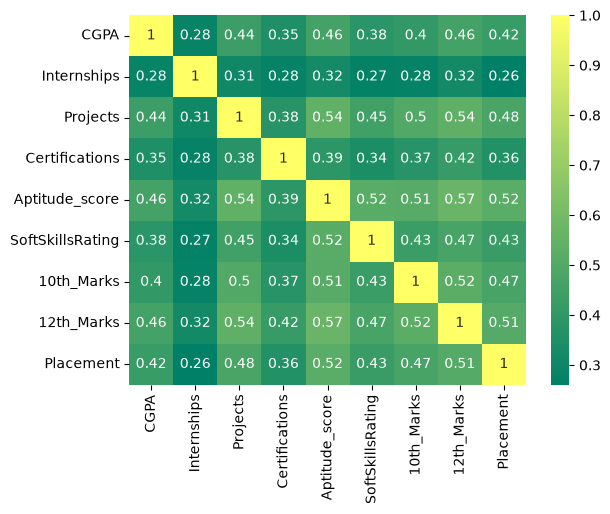

In [9]:
sns.heatmap(df.drop(columns=['Extracurricular','Training']).corr(),annot=True,cmap='summer')

In [10]:
df.duplicated().sum()

np.int64(72)

In [11]:
df['Placement'].value_counts()

Placement
0    5803
1    4197
Name: count, dtype: int64

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CGPA              10000 non-null  float64
 1   Internships       10000 non-null  int64  
 2   Projects          10000 non-null  int64  
 3   Certifications    10000 non-null  int64  
 4   Aptitude_score    10000 non-null  int64  
 5   SoftSkillsRating  10000 non-null  float64
 6   Extracurricular   10000 non-null  str    
 7   Training          10000 non-null  str    
 8   10th_Marks        10000 non-null  int64  
 9   12th_Marks        10000 non-null  int64  
 10  Placement         10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 911.4 KB


In [13]:
df.describe()

,CGPA,Internships,Projects,Certifications,Aptitude_score,SoftSkillsRating,10th_Marks,12th_Marks,Placement
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,7.698010,1.049200,2.026600,1.013200,79.449900,4.323960,69.159400,74.501500,0.419700
std,0.640131,0.665901,0.867968,0.904272,8.159997,0.411622,10.430459,8.919527,0.493534
min,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,55.000000,57.000000,0.000000
25%,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,59.000000,67.000000,0.000000
50%,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,70.000000,73.000000,0.000000
75%,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,78.000000,83.000000,1.000000
max,9.100000,2.000000,3.000000,3.000000,90.000000,4.800000,90.000000,88.000000,1.000000


In [14]:
df.isnull().sum()

CGPA                0
Internships         0
Projects            0
Certifications      0
Aptitude_score      0
SoftSkillsRating    0
Extracurricular     0
Training            0
10th_Marks          0
12th_Marks          0
Placement           0
dtype: int64

In [15]:
from sklearn.model_selection import train_test_split
X=df.drop(columns=['Placement'])
y=df['Placement']
X_train,X_temp,y_train,y_temp=train_test_split(X,y,train_size=0.6,random_state=31,stratify=y)
X_val,X_test,y_val,y_test=train_test_split(X_temp,y_temp,train_size=0.5,random_state=31,stratify=y_temp)

In [16]:
X_test


,CGPA,Internships,Projects,Certifications,Aptitude_score,SoftSkillsRating,Extracurricular,Training,10th_Marks,12th_Marks
9184,7.4,1,1,1,86,4.2,No,Yes,56,68
7568,7.4,1,1,1,70,3.5,No,Yes,57,61
7884,8.4,2,3,2,90,4.8,Yes,Yes,67,82
2862,8.3,2,2,2,90,4.7,Yes,No,73,81
2034,8.2,1,2,2,86,4.2,Yes,Yes,73,73
...,...,...,...,...,...,...,...,...,...,...
5463,7.2,1,2,1,74,3.7,No,No,55,72
8226,8.3,1,1,2,83,4.0,Yes,Yes,76,67
1222,6.9,1,3,2,86,4.4,Yes,Yes,79,70
142,8.4,1,3,2,90,4.6,Yes,Yes,67,80


In [16]:
import optuna
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import (GradientBoostingClassifier,AdaBoostClassifier,RandomForestClassifier,ExtraTreesClassifier)
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
numeric_cols = X_train.select_dtypes(
    include=np.number
).columns.tolist()
categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()
numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="passthrough"
)
def objective(trial):
    model_name = trial.suggest_categorical(
        "model",
        ["rf", "et", "gb", "logreg" , "dt" ,"lgbm","ab", "xgb"]
    )
    if model_name == "rf":
        model = RandomForestClassifier(
            n_estimators=trial.suggest_int("rf_n_estimators", 50, 200),
            max_depth=trial.suggest_int("rf_max_depth", 2, 20),
            max_features=trial.suggest_float("rf_max_features", 0.1, 1.0),
            max_samples=trial.suggest_float("rf_max_samples", 0.1, 1.0),
            criterion=trial.suggest_categorical("rf_criterion",['gini', 'entropy', 'log_loss']),bootstrap=True,random_state=31,n_jobs=-1)
    elif model_name == "logreg":
        model = LogisticRegression(
            C=trial.suggest_float("logreg_C", 1e-1, 10, log=True),
            penalty=trial.suggest_categorical("logreg_penalty",["l1", "l2"]),solver="liblinear",max_iter=trial.suggest_int("logreg_max_iter",50 , 200),
            random_state=31,n_jobs=-1
        )
    elif model_name == "dt":
        model = DecisionTreeClassifier(
            criterion=trial.suggest_categorical("dt_criterion",["gini", "entropy", "log_loss"]),
            splitter=trial.suggest_categorical("dt_splitter",["random", "best"]),
            max_depth=trial.suggest_int("dt_max_depth", 2, 20),
            min_samples_split=trial.suggest_int("dt_min_samples_split", 2, 10),
            min_samples_leaf=trial.suggest_int("dt_min_samples_leaf", 1,10),
            max_features=trial.suggest_categorical("dt_max_features",[None, "sqrt", "log2"]),random_state=31
        )
    elif model_name == "lgbm":
        model = LGBMClassifier(
            n_estimators=trial.suggest_int("lgbm_n_estimators", 50, 200),
            learning_rate=trial.suggest_float("lgbm_learning_rate",1e-2, 0.1,log=True),
            max_depth=trial.suggest_int("lgbm_max_depth", 2, 10),
            num_leaves=trial.suggest_int("lgbm_num_leaves", 10, 30),
            min_child_samples=trial.suggest_int("lgbm_min_child_samples", 5, 50),
            subsample=trial.suggest_float("lgbm_subsample", 0.5, 1.0),
            colsample_bytree=trial.suggest_float("lgbm_colsample_bytree", 0.5, 1.0),
            reg_alpha=trial.suggest_float("lgbm_reg_alpha",1e-4, 10,log=True),
            reg_lambda=trial.suggest_float("lgbm_reg_lambda",1e-2, 10,log=True),
            random_state=31,n_jobs=-1,verbosity=-1
        )
    elif model_name == "et":
        model = ExtraTreesClassifier(
            n_estimators=trial.suggest_int("et_n_estimators", 50, 200),
            max_depth=trial.suggest_int("et_max_depth", 2, 10),
            max_features=trial.suggest_float("et_max_features", 0.1, 1.0),
            max_samples=trial.suggest_float("et_max_samples", 0.1, 1.0),
            criterion=trial.suggest_categorical("et_criterion",['gini', 'entropy', 'log_loss']),
            bootstrap=True,
            random_state=3,
            n_jobs=-1
        )
    elif model_name == "gb":
        model = GradientBoostingClassifier(
            learning_rate=trial.suggest_float("gb_lr", 1e-2, 0.1, log=True),
            n_estimators=trial.suggest_int("gb_n_estimators", 50, 200),
            max_depth=trial.suggest_int("gb_max_depth", 2, 10),
            max_features=trial.suggest_float("gb_max_features", 0.1, 1.0),
            loss=trial.suggest_categorical("gb_loss",['log_loss', 'exponential']),random_state=3)
    elif model_name == "ab":
        model = AdaBoostClassifier(
            n_estimators=trial.suggest_int("ab_n_estimators", 50, 200),
            learning_rate=trial.suggest_float("ab_lr", 1e-2, 0.1, log=True),random_state=3
        )
    else:
        model = XGBClassifier(
            n_estimators=trial.suggest_int("xgb_n_estimators", 50, 200),
            learning_rate=trial.suggest_float("xgb_lr", 1e-2, 0.1, log=True),
            max_depth=trial.suggest_int("xgb_max_depth", 2, 10),
            min_child_weight=trial.suggest_int("xgb_min_child_weight", 1, 20),
            subsample=trial.suggest_float("xgb_subsample", 0.5, 1.0),
            colsample_bytree=trial.suggest_float("xgb_colsample_bytree", 0.5, 1.0),
            gamma=trial.suggest_float("xgb_gamma", 0, 10),
            reg_alpha=trial.suggest_float("xgb_reg_alpha", 1e-2, 10, log=True),
            reg_lambda=trial.suggest_float("xgb_reg_lambda", 1e-2, 10, log=True),random_state=3,n_jobs=-1
        )
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring="f1",
        n_jobs=-1
    )
    return scores.mean()
study = optuna.create_study(
    direction="maximize"
)
study.optimize(
    objective,
    n_trials=30
)
print("Best acc:", study.best_value)
print("\nBest parameters:")
print(study.best_params)
df_trials = study.trials_dataframe()
df_trials = df_trials.dropna(subset=["value"])
best_trials = (
    df_trials
    .sort_values("value", ascending=False)
    .groupby("params_model")
    .first()
)
for model_name, row in best_trials.iterrows():

    trial_number = int(row["number"])
    trial = study.trials[trial_number]

    print("\n" + "=" * 60)
    print(f"MODEL: {model_name}")
    print(f"BEST F1: {trial.value:.4f}")
    print("PARAMETERS:")

    for param, value in trial.params.items():
        if param != "model":
            print(f"  {param}: {value}")

C:\Users\Barun Rawat\AppData\Local\Temp\ipykernel_18144\973646386.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(
[I 2026-09-19 19:59:03,522] A new study created in memory with name: no-name-ec08cef1-5926-42bf-9500-793d88c35be2
[I 2026-09-19 19:59:11,718] Trial 0 finished with value: 0.7519759546984468 and parameters: {'model': 'rf', 'rf_n_estimators': 135, 'rf_max_depth': 5, 'rf_max_features': 0.6064999228239393, 'rf_max_samples': 0.8110058599802923, 'rf_criterion': 'entropy'}. Best is trial 0 with value: 0.7519759546984468.
[I 202

Best acc: 0.7608904699437563

Best parameters:
{'model': 'logreg', 'logreg_C': 9.24765473683961, 'logreg_penalty': 'l1', 'logreg_max_iter': 52}

MODEL: ab
BEST F1: 0.7554
PARAMETERS:
  ab_n_estimators: 151
  ab_lr: 0.03235484699443388

MODEL: dt
BEST F1: 0.7195
PARAMETERS:
  dt_criterion: entropy
  dt_splitter: random
  dt_max_depth: 13
  dt_min_samples_split: 4
  dt_min_samples_leaf: 10
  dt_max_features: log2

MODEL: et
BEST F1: 0.7538
PARAMETERS:
  et_n_estimators: 123
  et_max_depth: 4
  et_max_features: 0.3905281655756836
  et_max_samples: 0.9915702785035453
  et_criterion: log_loss

MODEL: gb
BEST F1: 0.7492
PARAMETERS:
  gb_lr: 0.022003707085567734
  gb_n_estimators: 114
  gb_max_depth: 3
  gb_max_features: 0.40483133641093905
  gb_loss: exponential

MODEL: lgbm
BEST F1: 0.7464
PARAMETERS:
  lgbm_n_estimators: 180
  lgbm_learning_rate: 0.07062892826653754
  lgbm_max_depth: 7
  lgbm_num_leaves: 12
  lgbm_min_child_samples: 14
  lgbm_subsample: 0.713143555571689
  lgbm_colsample_b

In [ ]:
import optuna
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import (GradientBoostingClassifier,AdaBoostClassifier,RandomForestClassifier,ExtraTreesClassifier)
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
numeric_cols = X_train.select_dtypes(
    include=np.number
).columns.tolist()
categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()
numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="passthrough"
)
def objective(trial):
    model_name = trial.suggest_categorical(
        "model",
        ["rf", "et", "gb", "logreg" , "dt" ,"lgbm","ab", "xgb"]
    )
    if model_name == "rf":
        model = RandomForestClassifier(
            n_estimators=trial.suggest_int("rf_n_estimators", 50, 200),
            max_depth=trial.suggest_int("rf_max_depth", 2, 20),
            max_features=trial.suggest_float("rf_max_features", 0.1, 1.0),
            max_samples=trial.suggest_float("rf_max_samples", 0.1, 1.0),
            criterion=trial.suggest_categorical("rf_criterion",['gini', 'entropy', 'log_loss']),bootstrap=True,random_state=31,n_jobs=-1)
    elif model_name == "logreg":
        model = LogisticRegression(
            C=trial.suggest_float("logreg_C", 1e-1, 10, log=True),
            penalty=trial.suggest_categorical("logreg_penalty",["l1", "l2"]),solver="liblinear",max_iter=trial.suggest_int("logreg_max_iter",50 , 200),
            random_state=31,n_jobs=-1
        )
    elif model_name == "dt":
        model = DecisionTreeClassifier(
            criterion=trial.suggest_categorical("dt_criterion",["gini", "entropy", "log_loss"]),
            splitter=trial.suggest_categorical("dt_splitter",["random", "best"]),
            max_depth=trial.suggest_int("dt_max_depth", 2, 20),
            min_samples_split=trial.suggest_int("dt_min_samples_split", 2, 10),
            min_samples_leaf=trial.suggest_int("dt_min_samples_leaf", 1,10),
            max_features=trial.suggest_categorical("dt_max_features",[None, "sqrt", "log2"]),random_state=31
        )
    elif model_name == "lgbm":
        model = LGBMClassifier(
            n_estimators=trial.suggest_int("lgbm_n_estimators", 50, 200),
            learning_rate=trial.suggest_float("lgbm_learning_rate",1e-2, 0.1,log=True),
            max_depth=trial.suggest_int("lgbm_max_depth", 2, 10),
            num_leaves=trial.suggest_int("lgbm_num_leaves", 10, 30),
            min_child_samples=trial.suggest_int("lgbm_min_child_samples", 5, 50),
            subsample=trial.suggest_float("lgbm_subsample", 0.5, 1.0),
            colsample_bytree=trial.suggest_float("lgbm_colsample_bytree", 0.5, 1.0),
            reg_alpha=trial.suggest_float("lgbm_reg_alpha",1e-4, 10,log=True),
            reg_lambda=trial.suggest_float("lgbm_reg_lambda",1e-2, 10,log=True),
            random_state=31,n_jobs=-1,verbosity=-1
        )
    elif model_name == "et":
        model = ExtraTreesClassifier(
            n_estimators=trial.suggest_int("et_n_estimators", 50, 200),
            max_depth=trial.suggest_int("et_max_depth", 2, 10),
            max_features=trial.suggest_float("et_max_features", 0.1, 1.0),
            max_samples=trial.suggest_float("et_max_samples", 0.1, 1.0),
            criterion=trial.suggest_categorical("et_criterion",['gini', 'entropy', 'log_loss']),
            bootstrap=True,
            random_state=3,
            n_jobs=-1
        )
    elif model_name == "gb":
        model = GradientBoostingClassifier(
            learning_rate=trial.suggest_float("gb_lr", 1e-2, 0.1, log=True),
            n_estimators=trial.suggest_int("gb_n_estimators", 50, 200),
            max_depth=trial.suggest_int("gb_max_depth", 2, 10),
            max_features=trial.suggest_float("gb_max_features", 0.1, 1.0),
            loss=trial.suggest_categorical("gb_loss",['log_loss', 'exponential']),random_state=3)
    elif model_name == "ab":
        model = AdaBoostClassifier(
            n_estimators=trial.suggest_int("ab_n_estimators", 50, 200),
            learning_rate=trial.suggest_float("ab_lr", 1e-2, 0.1, log=True),random_state=3
        )
    else:
        model = XGBClassifier(
            n_estimators=trial.suggest_int("xgb_n_estimators", 50, 200),
            learning_rate=trial.suggest_float("xgb_lr", 1e-2, 0.1, log=True),
            max_depth=trial.suggest_int("xgb_max_depth", 2, 10),
            min_child_weight=trial.suggest_int("xgb_min_child_weight", 1, 20),
            subsample=trial.suggest_float("xgb_subsample", 0.5, 1.0),
            colsample_bytree=trial.suggest_float("xgb_colsample_bytree", 0.5, 1.0),
            gamma=trial.suggest_float("xgb_gamma", 0, 10),
            reg_alpha=trial.suggest_float("xgb_reg_alpha", 1e-2, 10, log=True),
            reg_lambda=trial.suggest_float("xgb_reg_lambda", 1e-2, 10, log=True),random_state=3,n_jobs=-1
        )
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )
    return scores.mean()
study = optuna.create_study(
    direction="maximize"
)
study.optimize(
    objective,
    n_trials=30
)
print("Best acc:", study.best_value)
print("\nBest parameters:")
print(study.best_params)
df_trials = study.trials_dataframe()
df_trials = df_trials.dropna(subset=["value"])
best_trials = (
    df_trials
    .sort_values("value", ascending=False)
    .groupby("params_model")
    .first()
)
for model_name, row in best_trials.iterrows():
    trial_number = int(row["number"])
    trial = study.trials[trial_number]
    print("\n" + "=" * 60)
    print(f"MODEL: {model_name}")
    print(f"BEST F1: {trial.value:.4f}")
    print("PARAMETERS:")
    for param, value in trial.params.items():
        if param != "model":
            print(f"  {param}: {value}")

C:\Users\Barun Rawat\AppData\Local\Temp\ipykernel_18144\4125168083.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(
[I 2026-09-19 19:59:27,195] A new study created in memory with name: no-name-cc62f70f-a9bf-4638-b4c2-c016ba1e10e8
[I 2026-09-19 19:59:28,330] Trial 0 finished with value: 0.7958333333333334 and parameters: {'model': 'rf', 'rf_n_estimators': 105, 'rf_max_depth': 4, 'rf_max_features': 0.1068092717846915, 'rf_max_samples': 0.7263718691488058, 'rf_criterion': 'log_loss'}. Best is trial 0 with value: 0.7958333333333334.
[I 2

Best acc: 0.799

Best parameters:
{'model': 'logreg', 'logreg_C': 7.670506968856403, 'logreg_penalty': 'l1', 'logreg_max_iter': 161}

MODEL: ab
BEST F1: 0.7943
PARAMETERS:
  ab_n_estimators: 58
  ab_lr: 0.06830265774712815

MODEL: dt
BEST F1: 0.7668
PARAMETERS:
  dt_criterion: entropy
  dt_splitter: random
  dt_max_depth: 10
  dt_min_samples_split: 9
  dt_min_samples_leaf: 5
  dt_max_features: None

MODEL: et
BEST F1: 0.7960
PARAMETERS:
  et_n_estimators: 108
  et_max_depth: 9
  et_max_features: 0.10342471286318483
  et_max_samples: 0.6097901800705134
  et_criterion: gini

MODEL: gb
BEST F1: 0.7943
PARAMETERS:
  gb_lr: 0.01022724555720249
  gb_n_estimators: 199
  gb_max_depth: 2
  gb_max_features: 0.9948828546278738
  gb_loss: exponential

MODEL: lgbm
BEST F1: 0.7960
PARAMETERS:
  lgbm_n_estimators: 191
  lgbm_learning_rate: 0.07947305126853889
  lgbm_max_depth: 2
  lgbm_num_leaves: 19
  lgbm_min_child_samples: 15
  lgbm_subsample: 0.6941553245814645
  lgbm_colsample_bytree: 0.81432491

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
numeric_cols = X_train.select_dtypes(
    include=np.number
).columns.tolist()
categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()
numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="passthrough"
)
model = LogisticRegression(
        C=9.10765473683961,
        penalty='l1',solver="liblinear",max_iter=120,
        random_state=31,n_jobs=-1
    )
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])
pipe.fit(X_test,y_test)
from sklearn.metrics import classification_report, confusion_matrix
y_pred = pipe.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

C:\Users\Barun Rawat\AppData\Local\Temp\ipykernel_11504\3091542812.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(


Classification Report:
              precision    recall  f1-score   support

           0     0.8412    0.8303    0.8357      1161
           1     0.7693    0.7831    0.7761       839

    accuracy                         0.8105      2000
   macro avg     0.8053    0.8067    0.8059      2000
weighted avg     0.8110    0.8105    0.8107      2000


Confusion Matrix:
[[964 197]
 [182 657]]


c:\Users\Barun Rawat\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Barun Rawat\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\Barun Rawat\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspeci

In [18]:
import pickle
with open("placement.pkl", "wb") as f:
    pickle.dump((pipe,X_train), f)
